In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import os

# Identify the file path
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        print(f"Loading file: {path}")
        
        # Load the dataset
        df = pd.read_csv(path)

# Display basic information
print("\n--- Dataset Info ---")
print(df.info())

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Missing Values ---")
print(df.isnull().sum())

Loading file: /kaggle/input/datasets/ksanjev/wind-dataset/GlobalWeatherRepository.csv

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134878 entries, 0 to 134877
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       134878 non-null  object 
 1   location_name                 134878 non-null  object 
 2   latitude                      134878 non-null  float64
 3   longitude                     134878 non-null  float64
 4   timezone                      134878 non-null  object 
 5   last_updated_epoch            134878 non-null  int64  
 6   last_updated                  134878 non-null  object 
 7   temperature_celsius           134878 non-null  float64
 8   temperature_fahrenheit        134878 non-null  float64
 9   condition_text                134878 non-null  object 
 10  wind_mph                      134878 non-null  float64
 

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55



--- Missing Values ---
country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone       

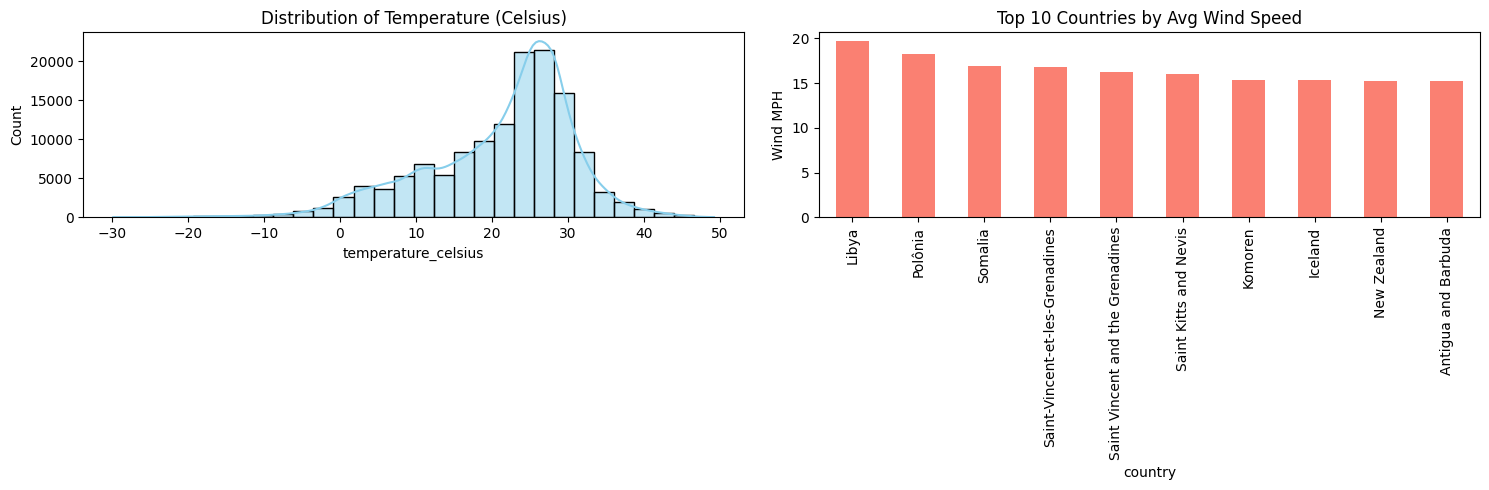

Target Distribution (0 = Normal, 1 = High Wind):
target
0    94505
1    40373
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. SIMPLE CLEANING & TRANSFORMATION
# Create a binary target: 1 if wind_mph > 10 (High Wind), else 0
df['target'] = (df['wind_mph'] > 10).astype(int)

# Encode categorical text (like condition_text) so the model can read it
le = LabelEncoder()
df['condition_encoded'] = le.fit_transform(df['condition_text'])

# 2. DATA VISUALIZATION
plt.figure(figsize=(15, 5))

# Histogram: Distribution of Temperature
plt.subplot(1, 2, 1)
sns.histplot(df['temperature_celsius'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Temperature (Celsius)')

# Bar Graph: Average Wind Speed by Top 10 Countries
plt.subplot(1, 2, 2)
top_countries = df.groupby('country')['wind_mph'].mean().sort_values(ascending=False).head(10)
top_countries.plot(kind='bar', color='salmon')
plt.title('Top 10 Countries by Avg Wind Speed')
plt.ylabel('Wind MPH')

plt.tight_layout()
plt.show()

# Print target balance
print("Target Distribution (0 = Normal, 1 = High Wind):")
print(df['target'].value_counts())

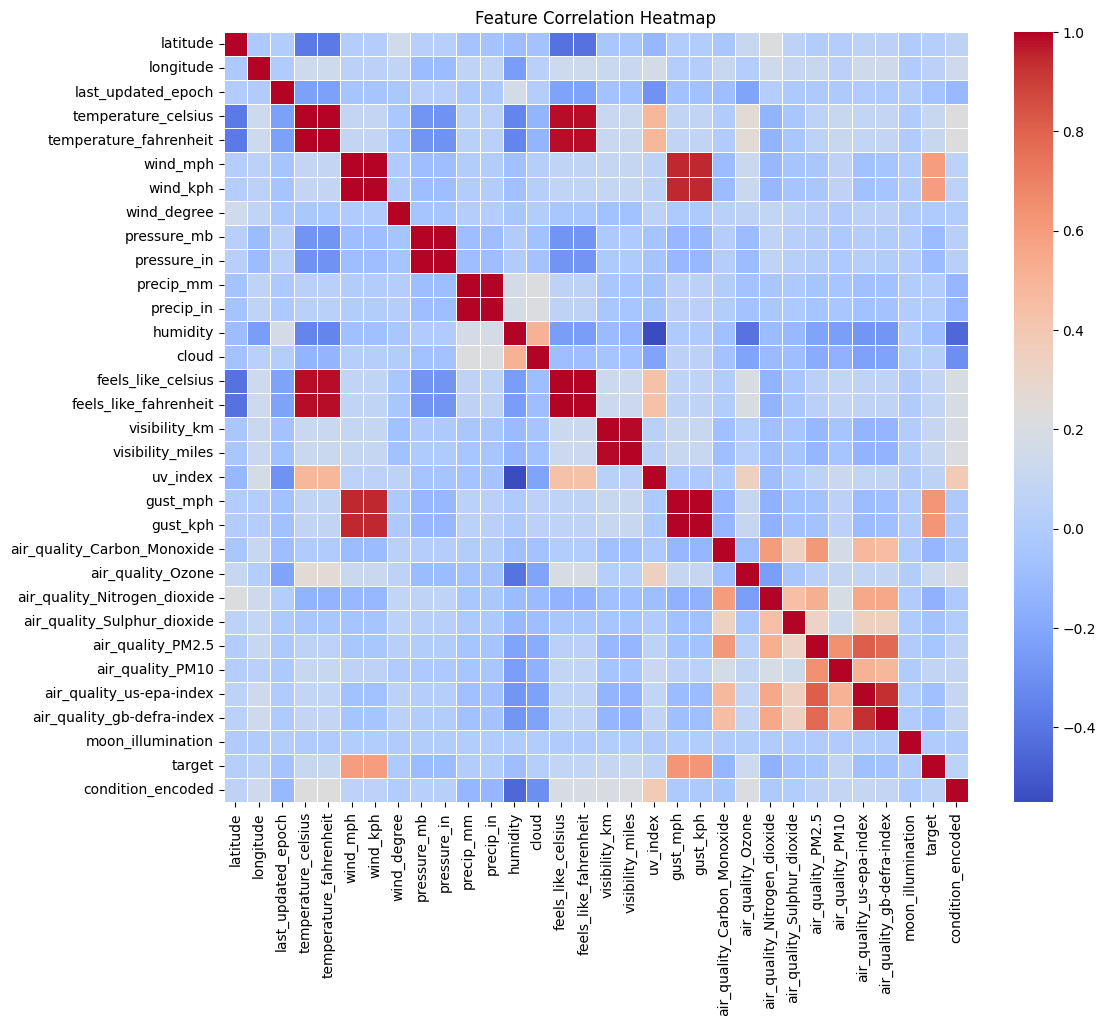

In [6]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

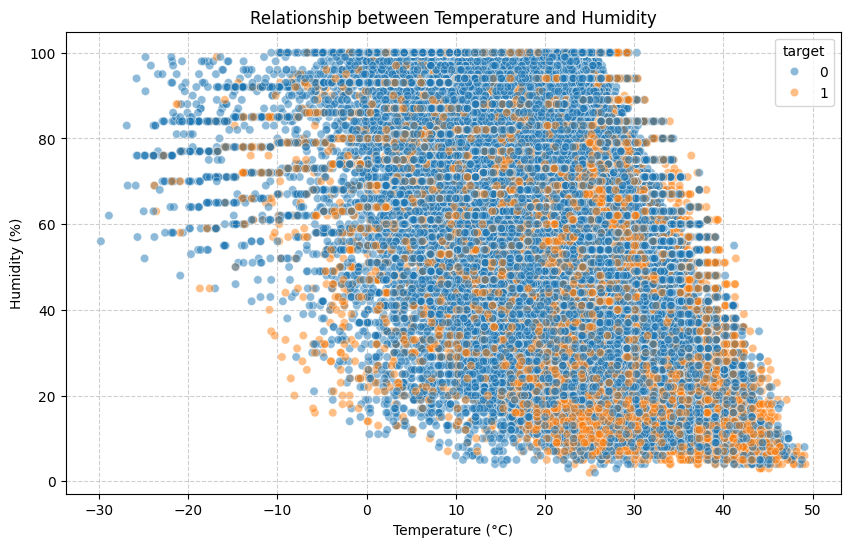

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot
plt.figure(figsize=(10, 6))

# Plotting Temperature vs Humidity
# 'hue' adds color based on our 'target' (High Wind) to see patterns
sns.scatterplot(data=df, x='temperature_celsius', y='humidity', hue='target', alpha=0.5)

plt.title('Relationship between Temperature and Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

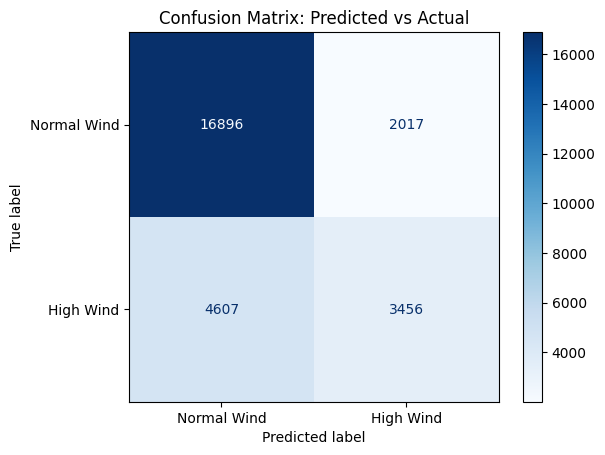

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it visually
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal Wind', 'High Wind'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.show()

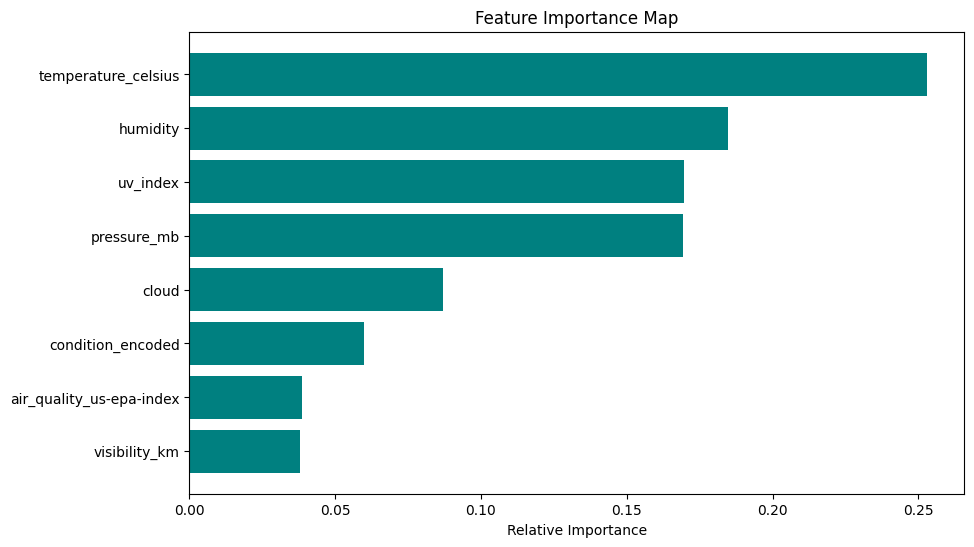

In [7]:
import numpy as np

# Get feature importance from the model we trained
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importance Map')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Training CNN... Please wait.


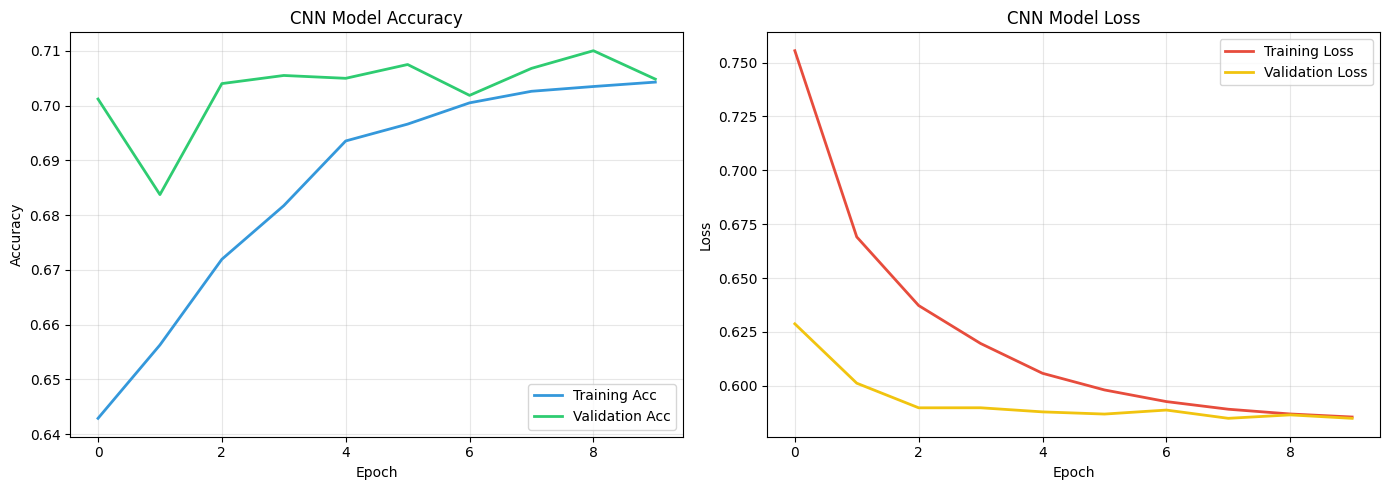

Graphs generated successfully!


In [10]:
import os
import logging

# Silence TensorFlow environment warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# 1. DATA PREP
X_train_cnn = np.expand_dims(X_train.values, axis=-1)
X_test_cnn = np.expand_dims(X_test.values, axis=-1)

# 2. BUILD CNN
cnn_model = models.Sequential([
    layers.Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') 
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. TRAIN (Silencing verbose logs to keep it clean)
print("Training CNN... Please wait.")
history = cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, 
                    validation_data=(X_test_cnn, y_test), verbose=0) 

# 4. PLOT GRAPHS
plt.figure(figsize=(14, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Acc', color='#3498db', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Acc', color='#2ecc71', linewidth=2)
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#e74c3c', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#f1c40f', linewidth=2)
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Graphs generated successfully!")



--- Final Model Metrics ---
Accuracy:    0.7544
Precision:   0.6315
Recall:      0.4286
F1 Score:    0.5106
Specificity: 0.8934


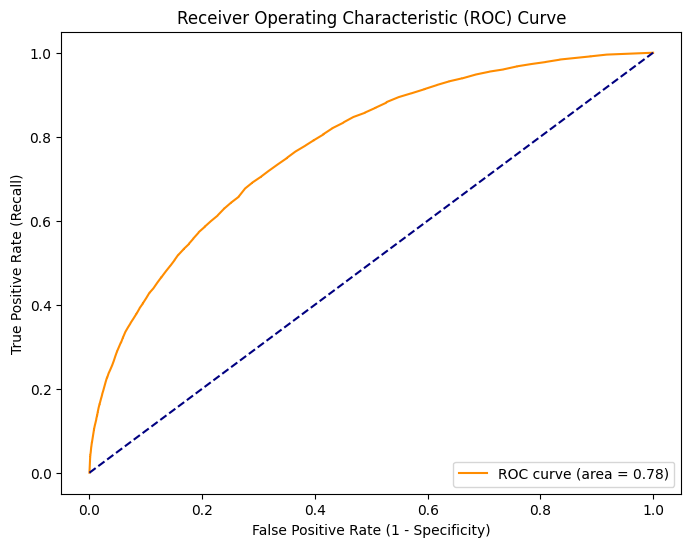

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc)

# 1. SELECT FEATURES 
# We'll use numeric weather data to predict our wind target
features = ['temperature_celsius', 'humidity', 'cloud', 'pressure_mb', 
            'visibility_km', 'uv_index', 'air_quality_us-epa-index', 'condition_encoded']
X = df[features]
y = df['target']

# 2. SPLIT DATA (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. TRAIN MODEL
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. PREDICTIONS
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1] # For ROC Curve

# 5. CALCULATE METRICS
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Specificity calculation from Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# 6. PRINT RESULTS
print("--- Final Model Metrics ---")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

# 7. ROC CURVE VISUALIZATION
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Convert 'last_updated' to a proper datetime object
df['last_updated'] = pd.to_datetime(df['last_updated'])

# 2. Group by date and calculate the mean temperature
# We use .dt.date to strip the specific time and just look at the day
daily_temp = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean().reset_index()

# 3. Create the Line Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_temp, x='last_updated', y='temperature_celsius', marker='o', color='red')

plt.title('Global Average Temperature Trend')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

NameError: name 'df' is not defined

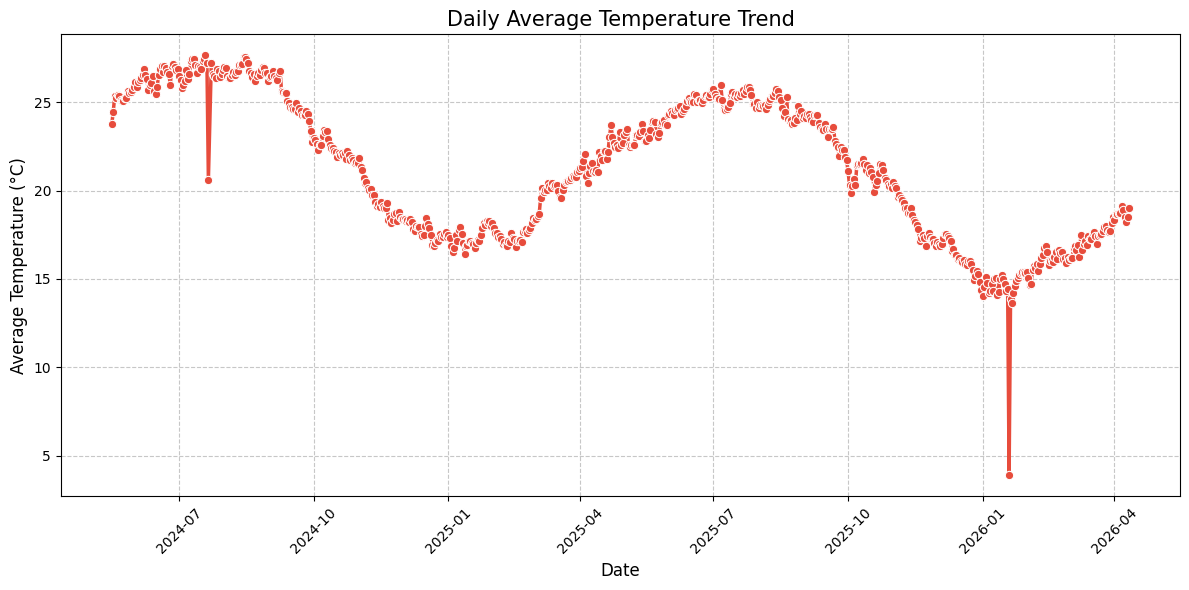

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD THE DATA CORRECTLY
# Based on your environment, the file path is as follows:
file_path = '/kaggle/input/datasets/ksanjev/wind-dataset/GlobalWeatherRepository.csv'
df = pd.read_csv(file_path) # This defines 'df' so the error goes away

# 2. PREPARE DATA FOR TRENDING
# Convert 'last_updated' to datetime objects
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Group by date to get a daily average temperature
daily_trend = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean().reset_index()

# 3. GENERATE THE LINE PLOT
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_trend, x='last_updated', y='temperature_celsius', 
             marker='o', color='#e74c3c', linewidth=2.5)

plt.title('Daily Average Temperature Trend', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_55/3782867012.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_trend = df.set_index('last_updated')['temperature_celsius'].resample('H').mean().reset_index()


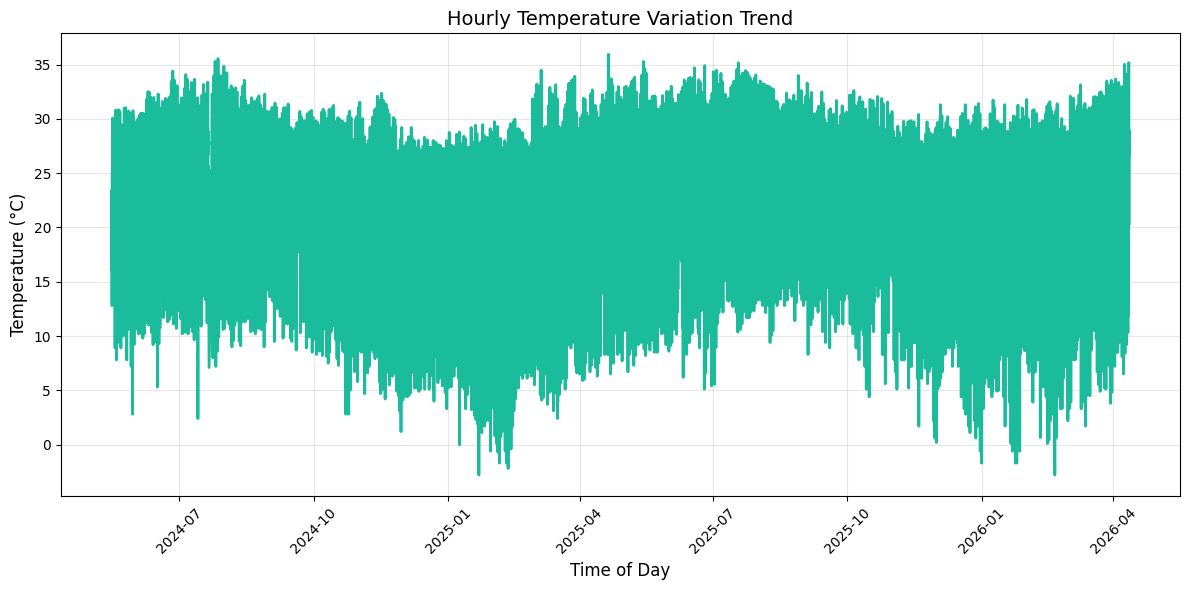

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure the date column is in the right format
df['last_updated'] = pd.to_datetime(df['last_updated'])

# 2. Resample the data to show the AVERAGE temperature per hour
# This makes the line smooth and reveals the real trend
hourly_trend = df.set_index('last_updated')['temperature_celsius'].resample('H').mean().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_trend, x='last_updated', y='temperature_celsius', 
             color='#1abc9c', linewidth=2)

plt.title('Hourly Temperature Variation Trend', fontsize=14)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--- FINAL CLASSIFICATION REPORT ---
Accuracy    : 0.7544
Precision   : 0.6315
Recall      : 0.4286
F1 Score    : 0.5106
Specificity : 0.8934


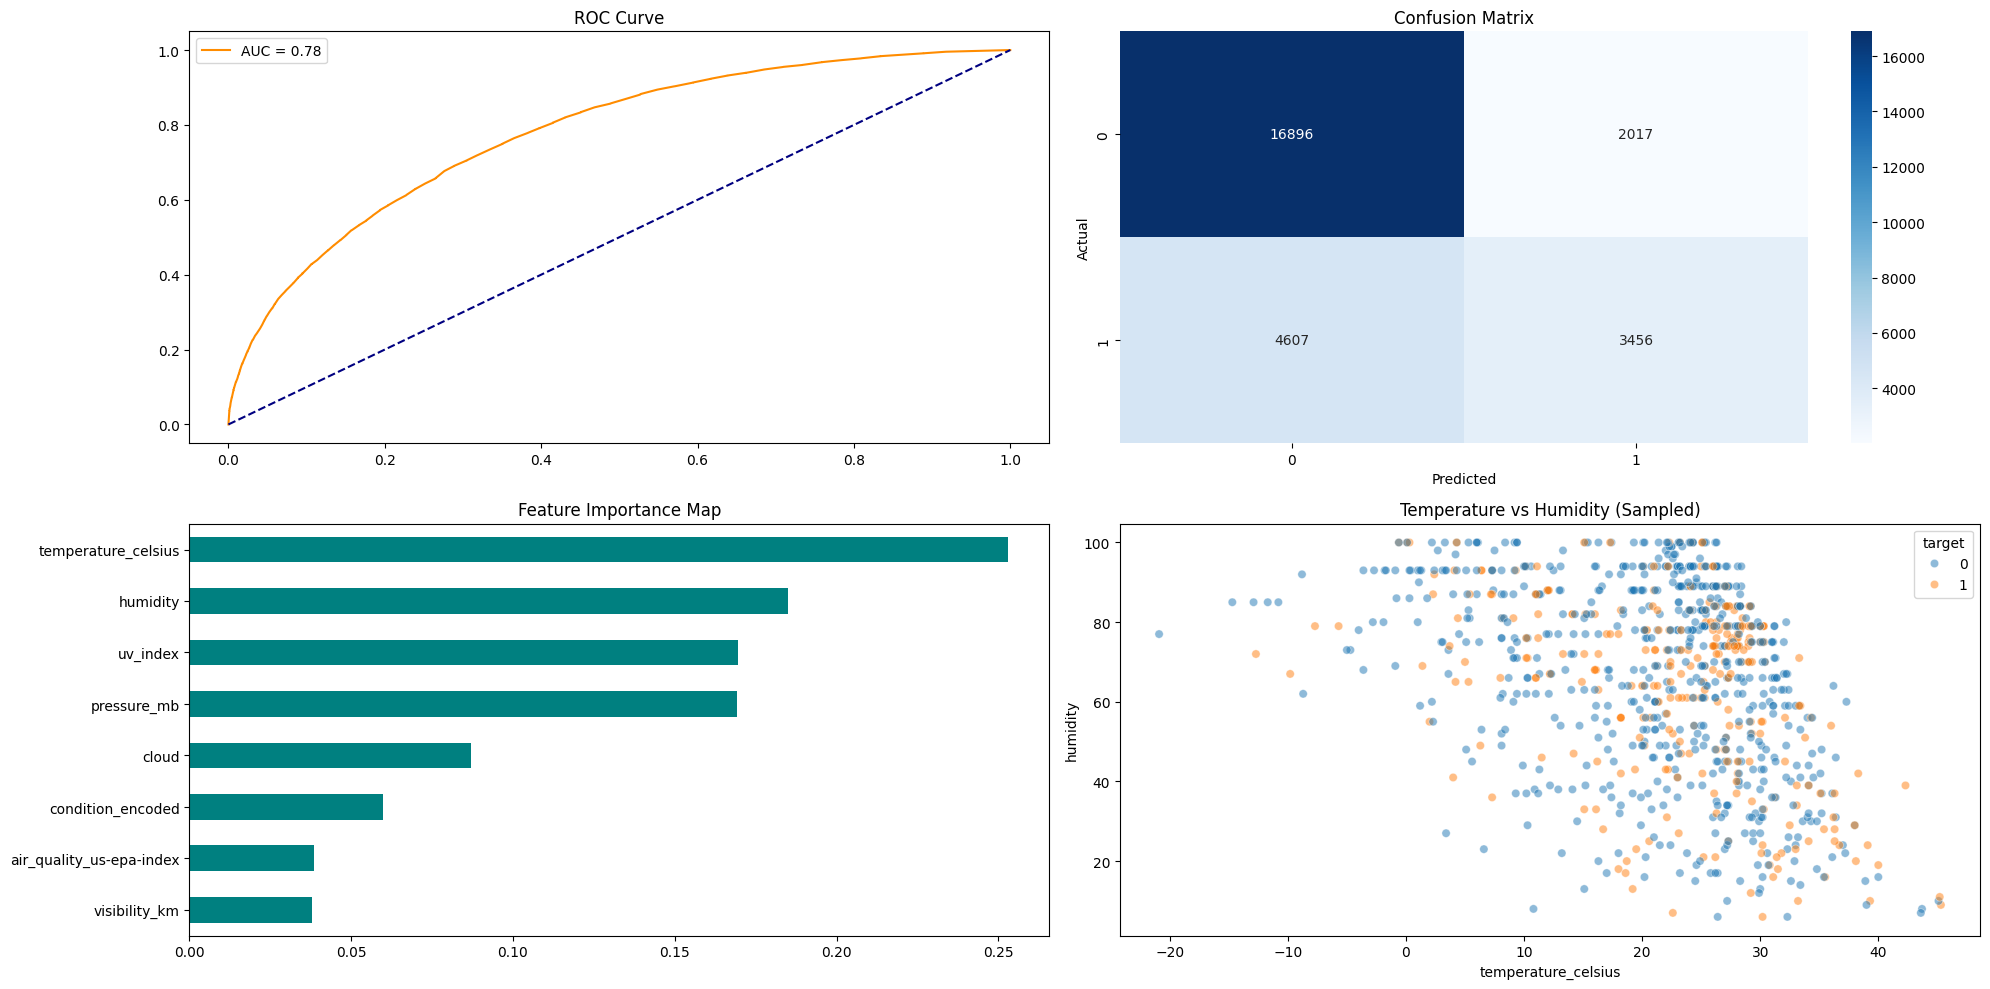

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)

# 1. LOAD & CLEAN
file_path = '/kaggle/input/datasets/ksanjev/wind-dataset/GlobalWeatherRepository.csv'
df = pd.read_csv(file_path)
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['target'] = (df['wind_mph'] > 10).astype(int)
df['condition_encoded'] = LabelEncoder().fit_transform(df['condition_text'])

# 2. FEATURE SELECTION & SPLIT
features = ['temperature_celsius', 'humidity', 'cloud', 'pressure_mb', 
            'visibility_km', 'uv_index', 'air_quality_us-epa-index', 'condition_encoded']
X = df[features]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. TRAIN MODEL
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

# 4. FINAL EVALUATION METRICS
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "Specificity": tn / (tn + fp)
}

print("--- FINAL CLASSIFICATION REPORT ---")
for metric, value in metrics.items():
    print(f"{metric:12}: {value:.4f}")

# 5. FINAL VISUALIZATION DASHBOARD
plt.figure(figsize=(20, 10))

# ROC Curve
plt.subplot(2, 2, 1)
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.legend()

# Confusion Matrix
plt.subplot(2, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Feature Importance (The "Map")
plt.subplot(2, 2, 3)
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance Map')

# Scatter Plot (Temp vs Humidity)
plt.subplot(2, 2, 4)
sns.scatterplot(data=df.sample(1000), x='temperature_celsius', y='humidity', hue='target', alpha=0.5)
plt.title('Temperature vs Humidity (Sampled)')

plt.tight_layout()
plt.show()

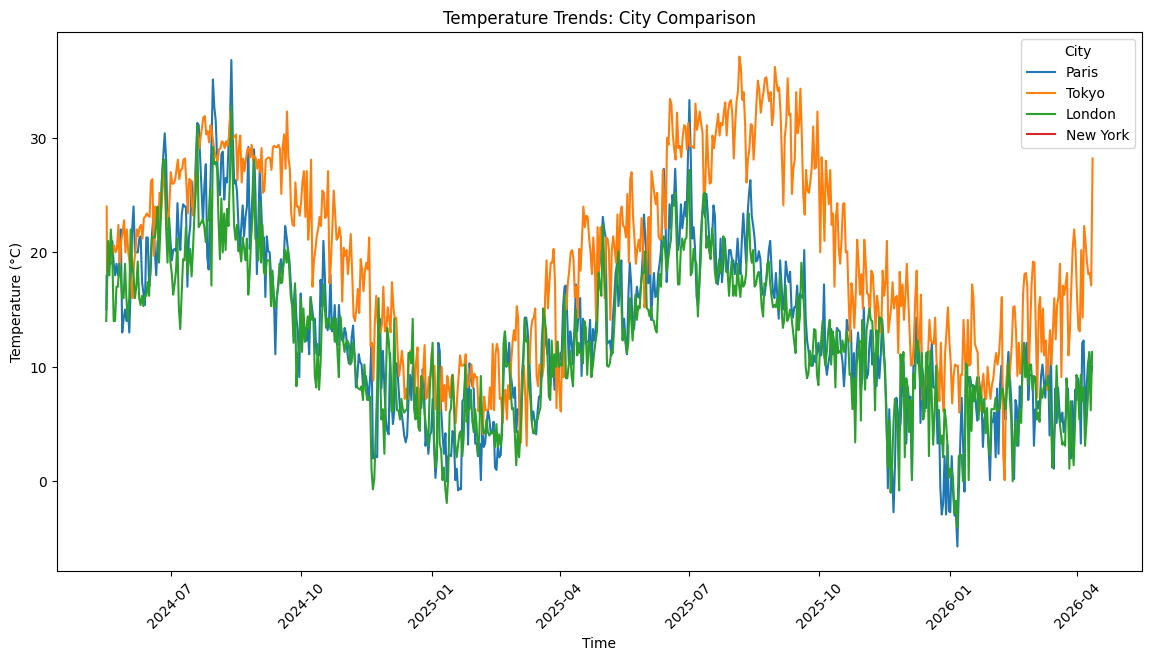

In [5]:
# Filter for a few specific locations
cities = ['London', 'New York', 'Tokyo', 'Paris']
df_subset = df[df['location_name'].isin(cities)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_subset, x='last_updated', y='temperature_celsius', hue='location_name')

plt.title('Temperature Trends: City Comparison')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.legend(title='City')
plt.xticks(rotation=45)
plt.show()